# RQ3: Pareto-optimal operating regimes (NSGA-II on GP surrogates, physics-verified)

Decision variables: load [0.60, 1.10], S/C [2.5, 4.0], inlet T [800, 900] K, excess air [5, 20] %, firing [0.85, 1.15];
inlet P and activity at base. Objectives: max H2 per tube, min fuel per kmol H2 (Q_comb / H2), min life-consumption per
kmol H2 (Yeh placeholder curve, relative to base). Constraints: dry CH4 slip <= base, T_wo,max <= 1193 K (920 degC,
design-limit assumption for HP-Nb), T_out <= 1125 K. NSGA-II pop 200 x 300 generations (seed 0); every final member
re-evaluated with the physics model. Base point: Plant A inputs with excess air 20 % (inside the decision bounds).
Results were produced by `rdt.optimize.run_all()` and are loaded here.

**Caveat on the fuel objective.** As specified it counts firebox fuel only; steam raising and feed preheat are free, so
the optimiser drives S/C and inlet T to their upper bounds. A sensitivity variant that charges steam raising (liquid
water at 25 degC to vapour at T_in) and dry-feed preheat as process heat is reported alongside.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdt import optimize as ox

pd.set_option("display.width", 250)
meta = json.loads((ox.OUT_DIR / "pareto_v1_meta.json").read_text())
par = pd.read_csv(ox.OUT_DIR / "pareto_v1.csv"); reg = pd.read_csv(ox.OUT_DIR / "regimes_v1.csv", index_col=0)
b = meta["base_reference"]
print(f"NSGA-II: {meta['n_evals']} surrogate evaluations in {meta['wall_time_s']:.0f} s; Pareto members {meta['n_pareto']}, feasible under physics {meta['n_feasible_phys']}")
print("max |surrogate - physics| per objective:", {k: round(v, 4) for k, v in meta["discrepancy_max"].items()})
print(f"base: H2 {b['H2']:.3f} kmol/h/tube, fuel {b['fuel_MJ_per_kmol_H2']:.1f} MJ/kmol H2, slip {b['slip']:.3f} %, T_wo,max {b['T_wo_max']:.1f} K, T_out {b['T_out']:.1f} K")
print("Pareto decision ranges:", {k: [round(v, 3) for v in r] for k, r in meta["decision_ranges_pareto"].items()})
print("\nbase domination:", meta["base_domination"])
print("\niso-production (H2 = base +/- 1 %):", json.dumps(meta["iso_production"], indent=1))
print("\nrepresentative regimes (physics-verified values):"); print(reg.round(3).T.to_string())
print("\nrobustness to a +/-20 K creep-curve shift (decision-space nearest-neighbour distances, normalised to the bounds):")
for k, v in meta["robustness"].items(): print(f"  {k}: mean {v['mean_nn_distance_norm']:.3f}, max {v['max_nn_distance_norm']:.3f}; S/C range {[round(x, 3) for x in v['decision_ranges']['steam_to_carbon']]}")
alt_path = ox.OUT_DIR / "pareto_v1_alt_totalheat_meta.json"
if alt_path.exists():
    alt = json.loads(alt_path.read_text())
    print(f"\nVARIANT fuel = Q_comb + steam raising + feed preheat: base {alt['ref_total_fuel_MJ_per_kmol_H2']:.1f} MJ/kmol H2; S/C range on the front {[round(x, 3) for x in alt['decision_ranges']['steam_to_carbon']]}")
    print(json.dumps(alt["iso_production"], indent=1))


NSGA-II: 60000 surrogate evaluations in 19 s; Pareto members 200, feasible under physics 199
max |surrogate - physics| per objective: {'H2_net_kmol_h': 0.0062, 'fuel_MJ_per_kmol_H2': 0.0628, 'life_rate_per_kmol_H2_rel_base': 0.0259}
base: H2 14.901 kmol/h/tube, fuel 157.5 MJ/kmol H2, slip 7.640 %, T_wo,max 1150.0 K, T_out 1111.3 K
Pareto decision ranges: {'feed_per_tube_fraction': [0.6, 1.1], 'steam_to_carbon': [3.92, 4.0], 'inlet_T': [800.315, 900.0], 'excess_air': [5.0, 19.998], 'specific_firing_factor': [0.85, 1.15]}

base domination: {'n_dominating': 50, 'n_pareto': 199, 'base_is_dominated': True, 'max_H2_gain_pct': 23.824922905795077, 'max_fuel_saving_pct': 19.158623618513147, 'max_life_saving_pct': 91.12523814857023}

iso-production (H2 = base +/- 1 %): {
 "n_in_band": 3,
 "min_life_idx": 12,
 "min_fuel_idx": 12,
 "min_life": {
  "life_rel_base": 0.15425357715835197,
  "fuel_penalty_pct": -18.975464127829124,
  "H2_rel_base_pct": -0.4704123241625724
 },
 "min_fuel": {
  "fuel_rel

/var/folders/g7/shk34hbn5fz79r0gnzgrs7640000gn/T/ipykernel_40949/282352364.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc_ = a.scatter(feas[xk], feas[yk], c=feas[ck] if ck else "C0", cmap="viridis", s=14, alpha=0.8, label="Pareto, physics-verified")


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig12_pareto.png


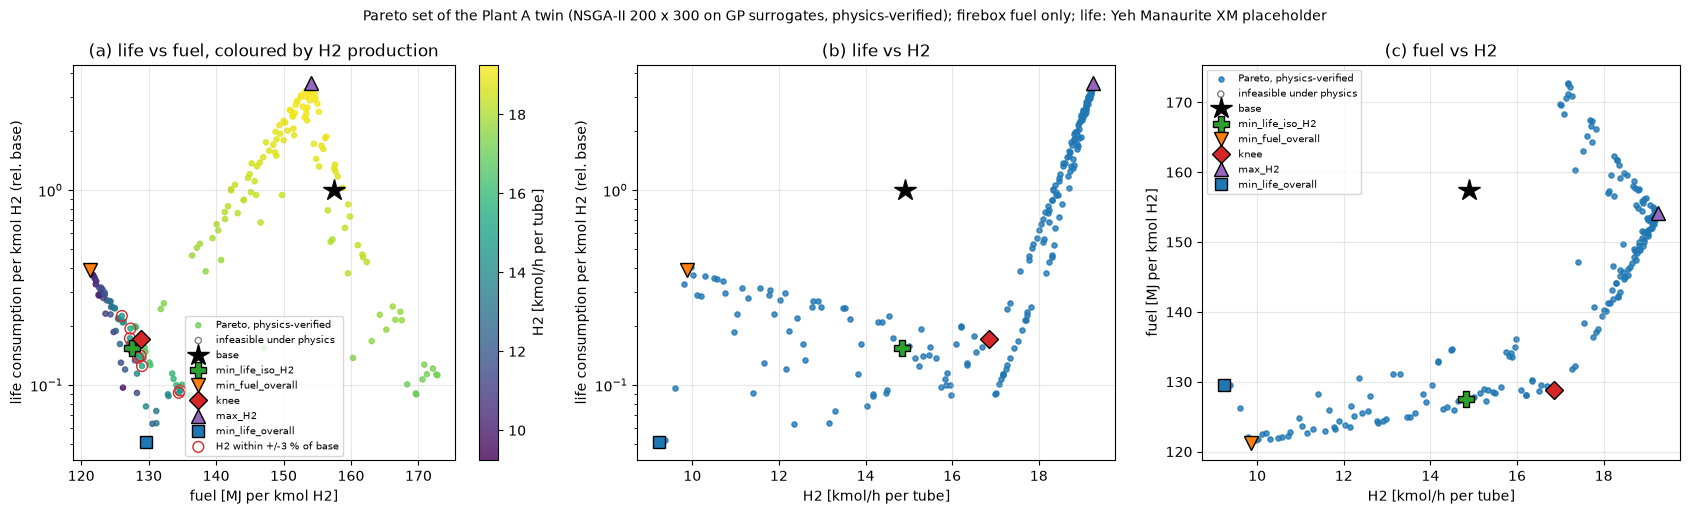

regimes plotted: ['base', 'min_life_iso_H2', 'min_fuel_overall', 'knee', 'max_H2', 'min_life_overall']


In [2]:
feas = par[par.feasible_phys]; infeas = par[~par.feasible_phys]
fig, ax = plt.subplots(1, 3, figsize=(17, 5.2))
marks = {"base": ("*", "k", 16), "min_life_iso_H2": ("P", "C2", 11), "min_fuel_overall": ("v", "C1", 10), "knee": ("D", "C3", 9), "max_H2": ("^", "C4", 10), "min_life_overall": ("s", "C0", 8)}
def panel(a, xk, yk, xl, yl, ck=None):
    sc_ = a.scatter(feas[xk], feas[yk], c=feas[ck] if ck else "C0", cmap="viridis", s=14, alpha=0.8, label="Pareto, physics-verified")
    if len(infeas): a.scatter(infeas[xk], infeas[yk], facecolors="none", edgecolors="grey", s=20, label="infeasible under physics")
    for name, (m, c, s) in marks.items():
        if name in reg.index: a.plot(reg.loc[name, xk], reg.loc[name, yk], marker=m, color=c, ms=s, ls="none", mec="k", label=name)
    a.set_xlabel(xl); a.set_ylabel(yl); a.grid(alpha=0.3)
    return sc_
s0 = panel(ax[0], "fuel_MJ_per_kmol_H2_phys", "life_rate_per_kmol_H2_rel_base_phys", "fuel [MJ per kmol H2]", "life consumption per kmol H2 (rel. base)", ck="H2_net_kmol_h_phys")
fig.colorbar(s0, ax=ax[0], label="H2 [kmol/h per tube]"); ax[0].set_yscale("log"); ax[0].set_title("(a) life vs fuel, coloured by H2 production")
band = feas[np.abs(feas.H2_net_kmol_h_phys / b["H2"] - 1) <= 0.03]
ax[0].scatter(band.fuel_MJ_per_kmol_H2_phys, band.life_rate_per_kmol_H2_rel_base_phys, facecolors="none", edgecolors="C3", s=60, label="H2 within +/-3 % of base")
ax[0].legend(fontsize=7)
panel(ax[1], "H2_net_kmol_h_phys", "life_rate_per_kmol_H2_rel_base_phys", "H2 [kmol/h per tube]", "life consumption per kmol H2 (rel. base)"); ax[1].set_yscale("log"); ax[1].set_title("(b) life vs H2")
panel(ax[2], "H2_net_kmol_h_phys", "fuel_MJ_per_kmol_H2_phys", "H2 [kmol/h per tube]", "fuel [MJ per kmol H2]"); ax[2].set_title("(c) fuel vs H2"); ax[2].legend(fontsize=7)
fig.suptitle("Pareto set of the Plant A twin (NSGA-II 200 x 300 on GP surrogates, physics-verified); firebox fuel only; life: Yeh Manaurite XM placeholder", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig12_pareto.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
print("regimes plotted:", [n for n in marks if n in reg.index])
